# Requirement 4 — Slightly Non-Stationary Environment, Multiple Campaigns

The environment is `AdversarialMultiCampaignEnv(mode='shocks')` — the same class as Requirement 3, parameterised for **piecewise-stationary** dynamics: 5 blocks of length 2 000 each, with the competing-bid distribution changing at each block boundary. All problem parameters (N=4, T=10 000, B=1 600, ρ=0.16, conflict edges (0,1) and (2,3)) are shared with Requirements 2 and 3.

**Three agents compared:**

1. **Sliding-Window Combinatorial-UCB** (`SlidingWindowCombinatorialUCBAgent`, W=2 000): discards samples older than one block length, forgetting stale statistics automatically.
2. **CUSUM Combinatorial-UCB** (`CUSUMCombinatorialUCBAgent`): detects changes per (campaign, bid) cell using CUSUM on the win indicator, resetting statistics on detection.
3. **Primal-Dual** (`PrimalDualMultiCampaignAgent`, Req 3): included as a reference — no explicit change detection, but enjoys the best-of-both-worlds guarantee of Requirement 3.

**Three benchmarks (reported together):**

| Tier | Oracle | What it knows |
|------|--------|---------------|
| **Primary** | Piecewise expected clairvoyant | Block boundaries + true per-block distributions; not individual $m_t$ |
| Secondary | OPT$^A$ | Best fixed distribution in hindsight (same methodology as Req 3) |
| Reference | Dynamic / prophet | Every realised $m_t$ — inflates regret by a linear-in-$T$ Jensen gap |

The primary benchmark is the natural target for SW-UCB and CUSUM-UCB: it represents what a learner knowing only the block structure — not individual realisations — could achieve in expectation. The dynamic oracle is reported for completeness only; its informational advantage over the learner cannot be closed regardless of algorithm quality.

In [5]:
import sys
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s")

DATA_DIR    = ROOT / "data" / "picklefiles"
OUTPUTS_DIR = ROOT / "outputs"

def load_pickle(name):
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run the experiment cell first.")
    with path.open("rb") as f:
        return pickle.load(f)

def show_png(relative_path, width=900):
    path = OUTPUTS_DIR / relative_path
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"*Missing plot:* `{path}` — run the experiment cell first."))

2026-07-09 15:10:38,371 | ============================================================
2026-07-09 15:10:38,371 | Requirement 4 - Slightly Non-Stationary, Multiple Campaigns
2026-07-09 15:10:38,373 | ============================================================
2026-07-09 15:10:38,373 | Parameters | N=4 T=10000 B=1600.0 rho=0.1600 n_intervals=5 block_size=2000 sw_window=2000 U_T=4 pd_ogd_eta=0.0170 budget_pacing=True
2026-07-09 15:10:38,377 | AdversarialMultiCampaignEnv | N=4 T=10000 B=1600.0 rho=0.1600 mode=shocks conflict_edges=[(0, 1), (2, 3)]
2026-07-09 15:10:38,377 | No cache at C:\Users\giuli\Repositories\ola\data\picklefiles\clairvoyant_dyn_6fc84cb556e7.pkl -- will compute on the fly (slow).
2026-07-09 15:10:38,377 | No dynamic/prophet clairvoyant cache found for key=6fc84cb556e7 -- run `python -m utils.precompute_clairvoyant_req4` to populate the upper-bound reference curve. The primary (piecewise-expected) and secondary (OPT^A) benchmarks below do not need it.
2026-07-09 15:10:3

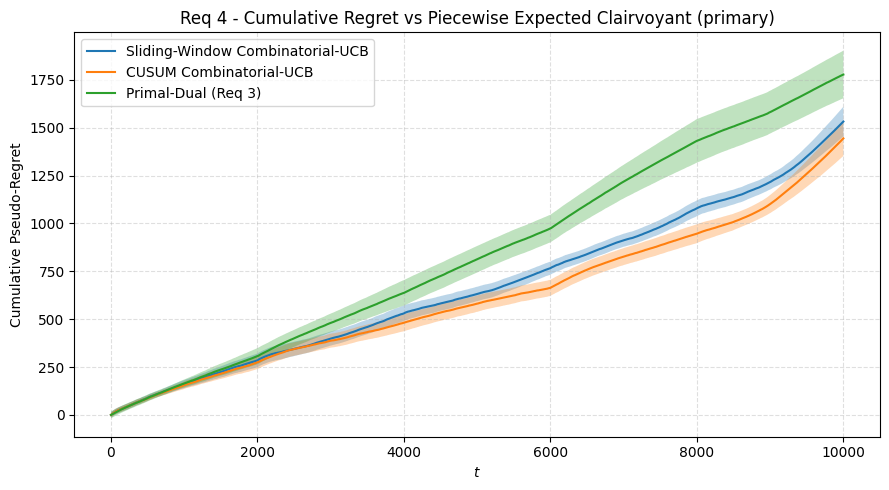

2026-07-09 16:31:19,716 | Saved plot to C:\Users\giuli\Repositories\ola\outputs\r4\req4_regret_opta.png


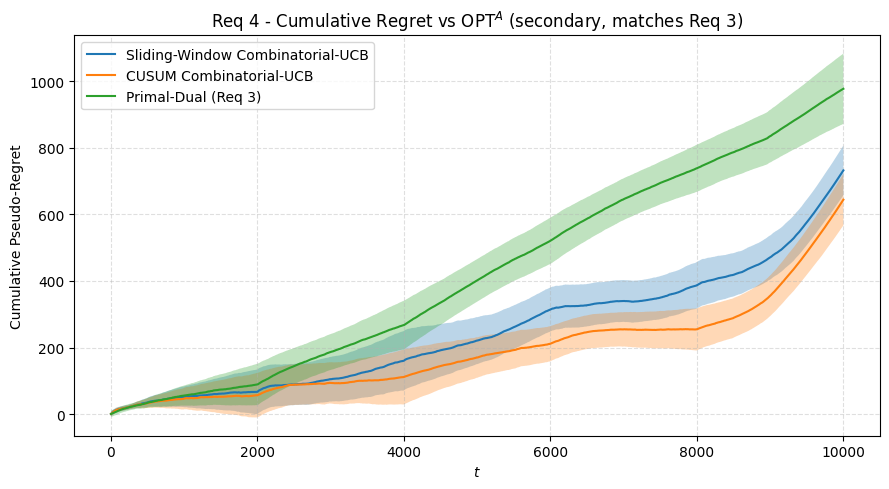

2026-07-09 16:31:20,291 | Saved plot to C:\Users\giuli\Repositories\ola\outputs\r4\req4_regret_prophet.png


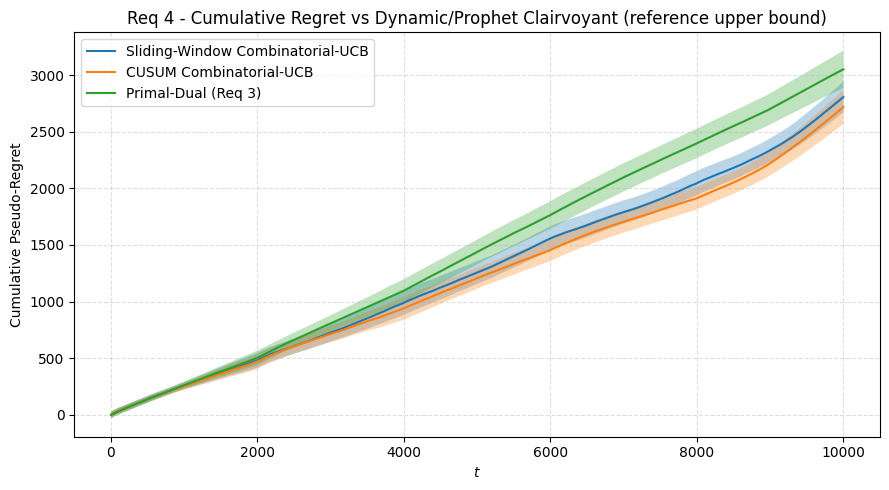

2026-07-09 16:31:20,822 | Saved plot to C:\Users\giuli\Repositories\ola\outputs\r4\req4_budget.png


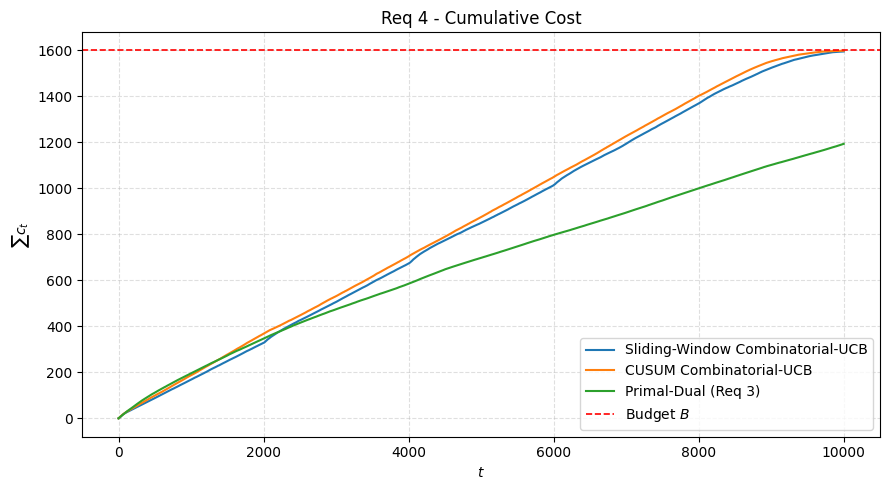

2026-07-09 16:31:21,259 | Saved plot to C:\Users\giuli\Repositories\ola\outputs\r4\req4_cusum_resets.png
2026-07-09 16:31:21,524 | Saved plot to C:\Users\giuli\Repositories\ola\outputs\r4\req4_lambda.png
2026-07-09 16:31:21,525 | ============================================================
2026-07-09 16:31:21,526 | Final regret (mean over 20 trials):
2026-07-09 16:31:21,528 |                           piecewise      OPT^A    prophet
2026-07-09 16:31:21,531 |   Sliding-Window Combinatorial-UCB    1532.01     732.66    2805.60
2026-07-09 16:31:21,532 |   CUSUM Combinatorial-UCB    1443.90     644.55    2717.49
2026-07-09 16:31:21,533 |   Primal-Dual (Req 3)       1777.40     978.05    3050.99
2026-07-09 16:31:21,534 | Mean CUSUM resets per trial: 55.4
2026-07-09 16:31:21,535 | Final cumulative cost:
2026-07-09 16:31:21,536 |   Sliding-Window Combinatorial-UCB 1595.52 / 1600
2026-07-09 16:31:21,537 |   CUSUM Combinatorial-UCB 1598.91 / 1600
2026-07-09 16:31:21,539 |   Primal-Dual (Req 3) 

{'sw': {'mean_regret': array([5.44820417e-01, 1.08964083e+00, 1.48446125e+00, ...,
         2.80451453e+03, 2.80505935e+03, 2.80560417e+03], shape=(10000,)),
  'std_regret': array([1.62182269e-01, 3.24364539e-01, 5.04178412e-01, ...,
         6.10482084e+02, 6.10635367e+02, 6.10788654e+02], shape=(10000,)),
  'mean_cumcost': array([0.000000e+00, 0.000000e+00, 2.000000e-02, ..., 1.595515e+03,
         1.595515e+03, 1.595515e+03], shape=(10000,)),
  'n_trials': 20,
  'mean_regret_piecewise': array([4.46562756e-01, 8.93125513e-01, 1.18968827e+00, ...,
         1.53122935e+03, 1.53162053e+03, 1.53201170e+03], shape=(10000,)),
  'std_regret_piecewise': array([2.59641998e-01, 5.19283997e-01, 7.12228484e-01, ...,
         3.44940170e+02, 3.45160474e+02, 3.45380821e+02], shape=(10000,)),
  'mean_regret_opt_a': array([3.37526370e-01, 6.75052740e-01, 8.62579110e-01, ...,
         7.31988648e+02, 7.32326174e+02, 7.32663701e+02], shape=(10000,)),
  'std_regret_opt_a': array([1.18649433e-01, 2.3729

In [6]:
from utils.run_req4 import run_req4
run_req4()

In [7]:
try:
    res_sw    = load_pickle("req4_sw_cucb_results.pkl")
    res_cusum = load_pickle("req4_cusum_cucb_results.pkl")
    res_pd    = load_pickle("req4_primal_dual_results.pkl")
except FileNotFoundError as _e:
    display(Markdown(f"**Run the `run_req4()` cell above first, then re-run this cell.**\n\n`{_e}`"))
    raise

agents = [
    ("CUSUM Combinatorial-UCB",          res_cusum),
    ("Sliding-Window Combinatorial-UCB", res_sw),
    ("Primal-Dual (Req 3)",              res_pd),
]

def _fmt(res, key):
    arr = res.get(key)
    return f"{arr[-1]:.1f}" if arr is not None else "—"

rows = ["| Agent | Piecewise (primary) | OPT^A (secondary) | Prophet (reference) | Cost / B |",
        "| --- | --- | --- | --- | --- |"]
for label, res in agents:
    pw   = _fmt(res, "mean_regret_piecewise")
    oa   = _fmt(res, "mean_regret_opt_a")
    prph = f"{res['mean_regret'][-1]:.1f}"
    cost = f"{res['mean_cumcost'][-1]:.1f} / 1600"
    rows.append(f"| {label} | {pw} | {oa} | {prph} | {cost} |")
display(Markdown("\n".join(rows)))

| Agent | Piecewise (primary) | OPT^A (secondary) | Prophet (reference) | Cost / B |
| --- | --- | --- | --- | --- |
| CUSUM Combinatorial-UCB | 1443.9 | 644.6 | 2717.5 | 1598.9 / 1600 |
| Sliding-Window Combinatorial-UCB | 1532.0 | 732.7 | 2805.6 | 1595.5 / 1600 |
| Primal-Dual (Req 3) | 1777.4 | 978.0 | 3051.0 | 1193.9 / 1600 |

## Regret and Average Regret

Regret is measured against the primary benchmark (piecewise expected clairvoyant). The ranking CUSUM < SW-UCB < Primal-Dual is consistent across all three benchmarks.

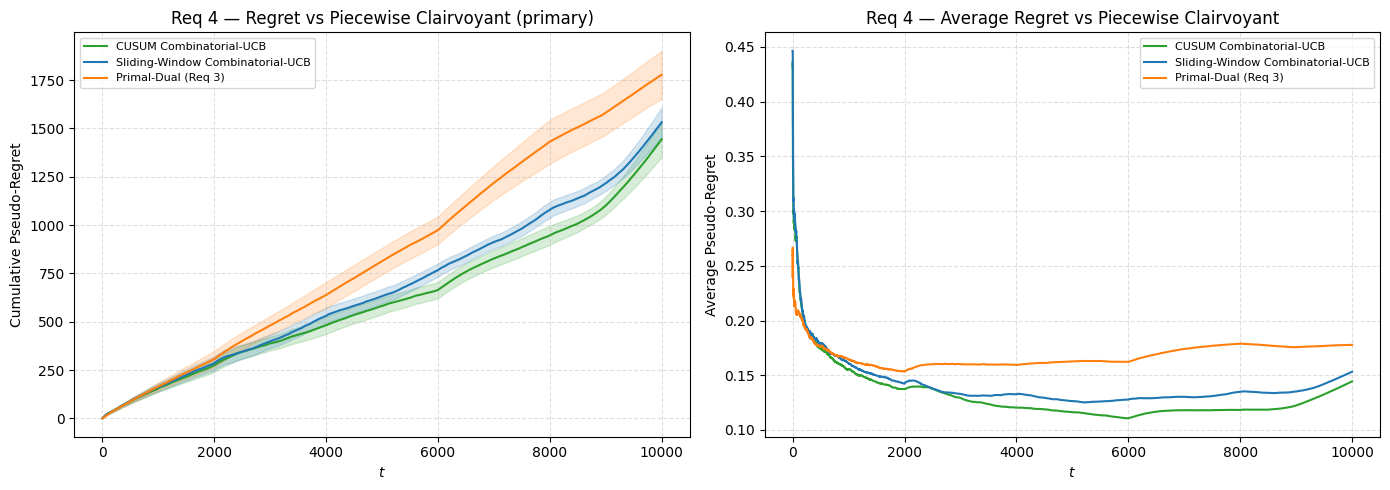

In [8]:
T_run = len(res_sw["mean_regret"])
ts    = np.arange(1, T_run + 1)
colors = {"CUSUM Combinatorial-UCB": "C2",
          "Sliding-Window Combinatorial-UCB": "C0",
          "Primal-Dual (Req 3)": "C1"}

def _piecewise_mean(res):
    return np.array(res.get("mean_regret_piecewise", res["mean_regret"]))

def _piecewise_std(res):
    return np.array(res.get("std_regret_piecewise", res["std_regret"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, res in agents:
    mean   = _piecewise_mean(res)
    stderr = _piecewise_std(res) / np.sqrt(res["n_trials"])
    ax.plot(ts, mean, label=label, color=colors[label])
    ax.fill_between(ts, mean - stderr, mean + stderr, alpha=0.18, color=colors[label])
ax.set_xlabel("$t$"); ax.set_ylabel("Cumulative Pseudo-Regret")
ax.set_title("Req 4 — Regret vs Piecewise Clairvoyant (primary)")
ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.4)

ax = axes[1]
for label, res in agents:
    mean = _piecewise_mean(res)
    ax.plot(ts, mean / ts, label=label, color=colors[label])
ax.set_xlabel("$t$"); ax.set_ylabel("Average Pseudo-Regret")
ax.set_title("Req 4 — Average Regret vs Piecewise Clairvoyant")
ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout(); plt.show()

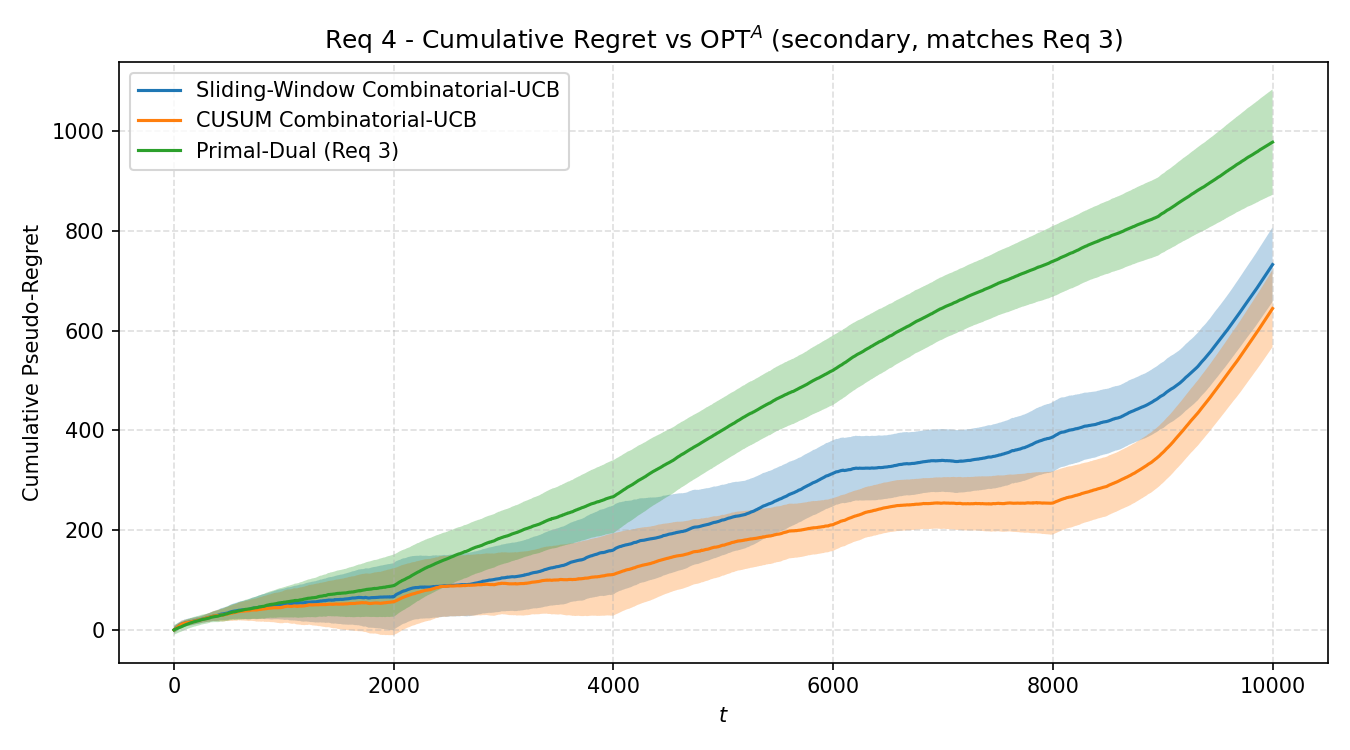

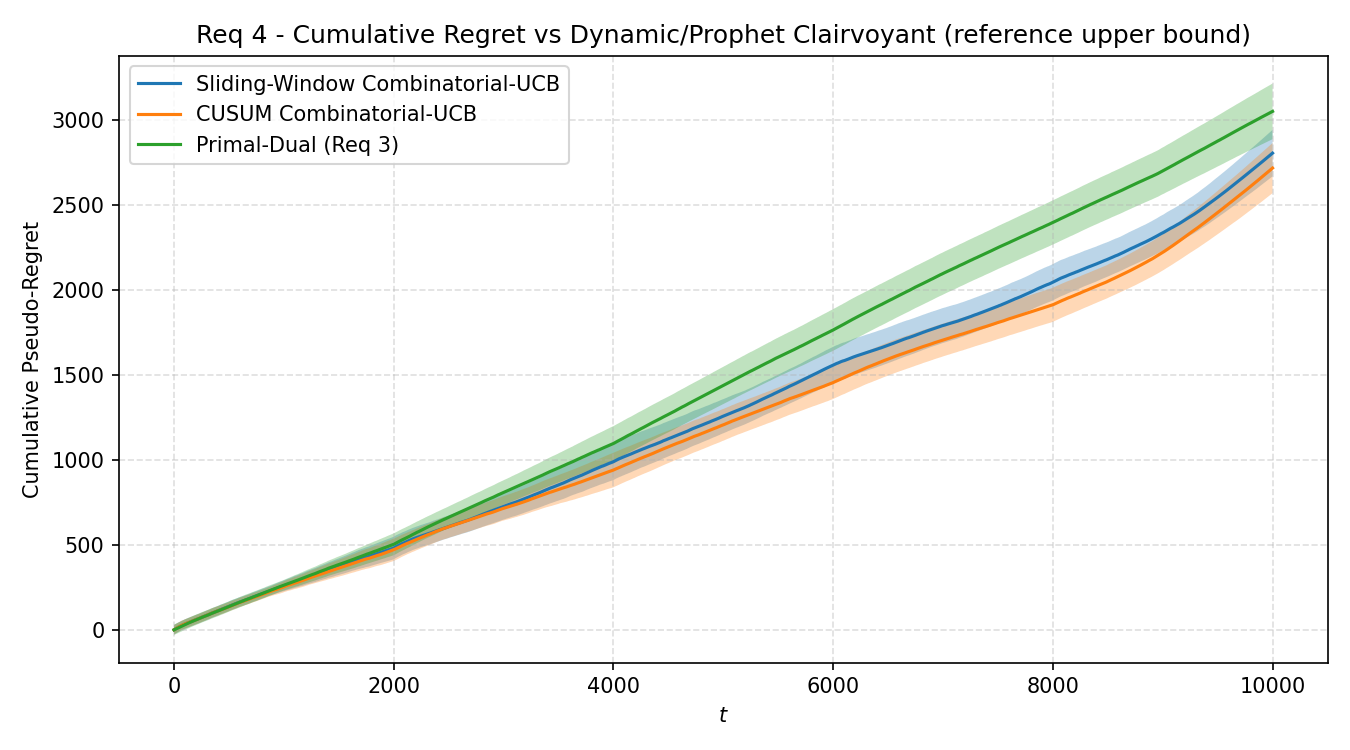

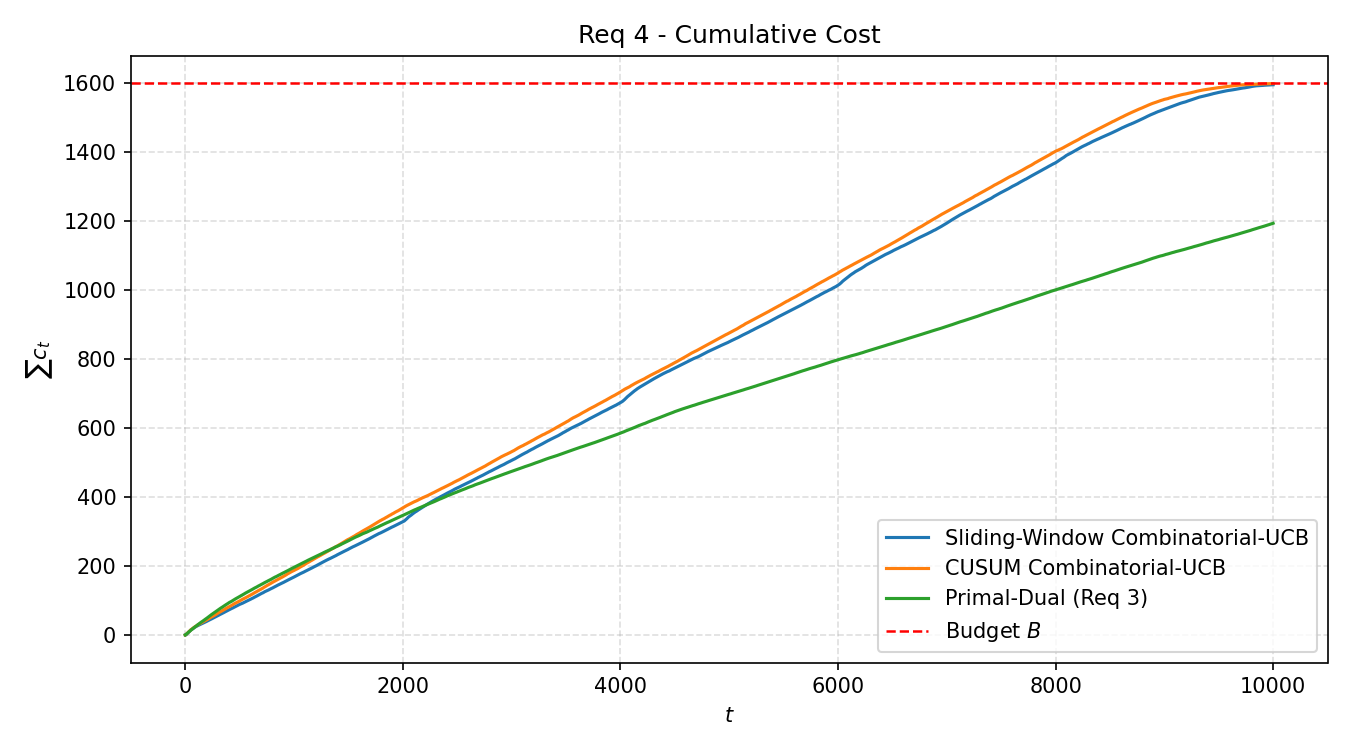

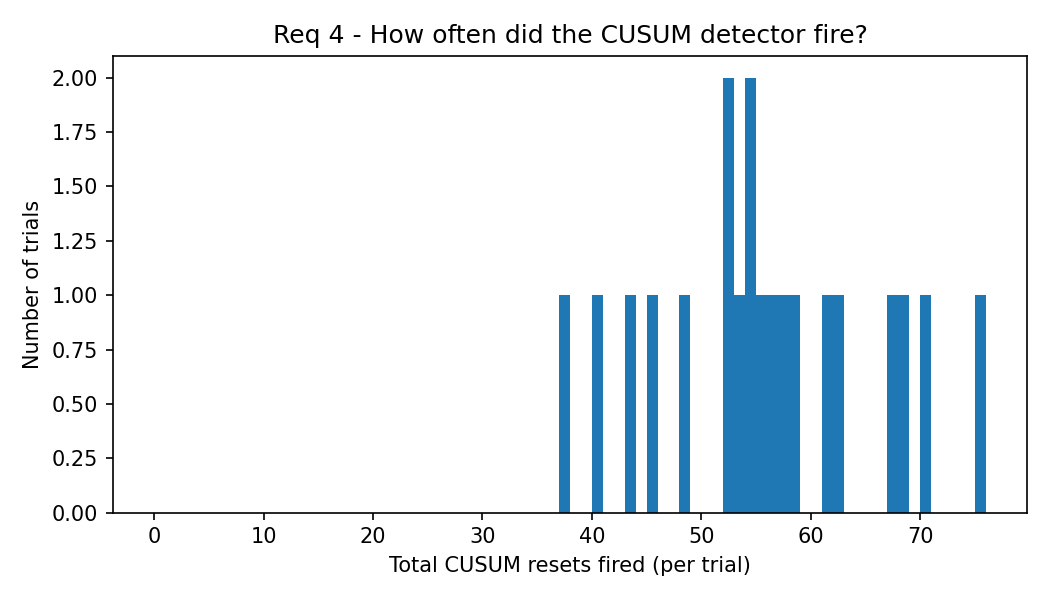

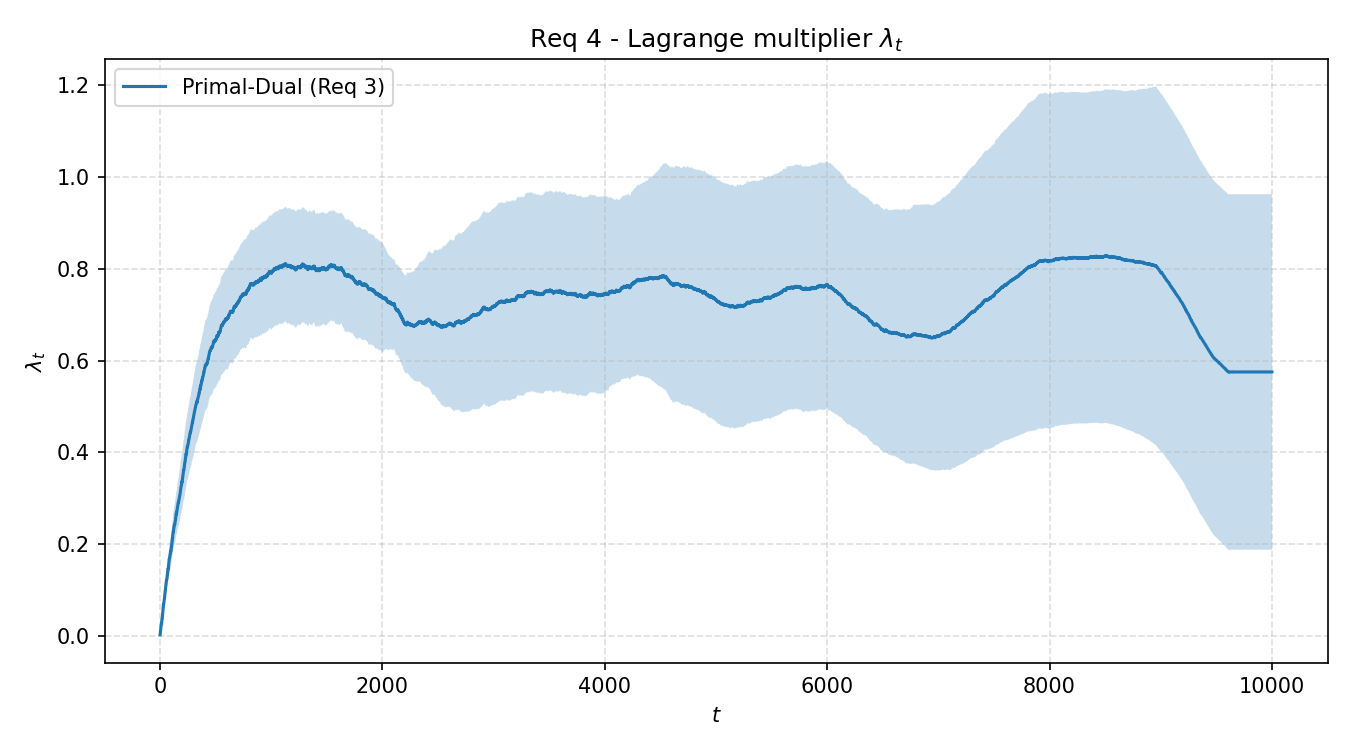

In [9]:
for path in [
    "r4/req4_regret_opta.png",
    "r4/req4_regret_prophet.png",
    "r4/req4_budget.png",
    "r4/req4_cusum_resets.png",
    "r4/req4_lambda.png",
]:
    show_png(path)

## Interpretation

- **The ranking is identical under all three benchmarks** (CUSUM < SW-UCB < Primal-Dual), confirming the conclusion is robust to the choice of oracle.
- **The benchmark scale change is itself informative.** Moving from the dynamic/prophet oracle to the piecewise expected clairvoyant roughly halves every agent's regret number. This is direct evidence of the Jensen-gap argument: a large share of "regret" against the prophet reflects the unavoidable informational asymmetry of not knowing realised $m_t$, not a learning failure.
- **CUSUM achieves the best regret** by explicitly detecting and resetting on the 4 true regime boundaries per trial. It fires roughly 55 times per trial across all 38 (campaign, bid) cells — some false positives are expected, but the reset cost is low relative to the gain from discarding stale statistics.
- **SW-UCB** (W=2 000, equal to block length) closely tracks CUSUM. Using the textbook $W \approx 2\sqrt{T} \approx 200$ would be too short: with 38 cells and a budget LP, many cells would not accumulate enough samples within a window before the LP starts making unreliable recommendations.
- **Primal-Dual's gap** is driven by budget under-utilisation (~74% of $B$ spent vs ~99.8% for the other two). The dual price $\lambda_t$ suppresses bidding after a regime shift without an explicit reset mechanism, causing the agent to "wait and see" longer than necessary before resuming aggressive bidding.